Different Types of Analysis =univariate,bivariate or numerical analysis

In [1]:
#dataset info:sample data set containing customer data and showing customers who have left last month

In [11]:
#import the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
telco_base_data=pd.read_csv("Churn_Modelling.csv")

In [13]:
telco_base_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Univariate Analysis

In [14]:
telco_new=telco_base_data[['Geography','Gender','Exited']] #categorical data
telco_new

,Geography,Gender,Exited
0,France,Female,1
1,Spain,Female,0
2,France,Female,1
3,France,Female,0
4,Spain,Female,0
...,...,...,...
9995,France,Male,0
9996,France,Male,0
9997,France,Female,1
9998,Germany,Male,1


In [15]:
telco_new.Exited.value_counts()/len(telco_new)*100

Exited
0    79.63
1    20.37
Name: count, dtype: float64

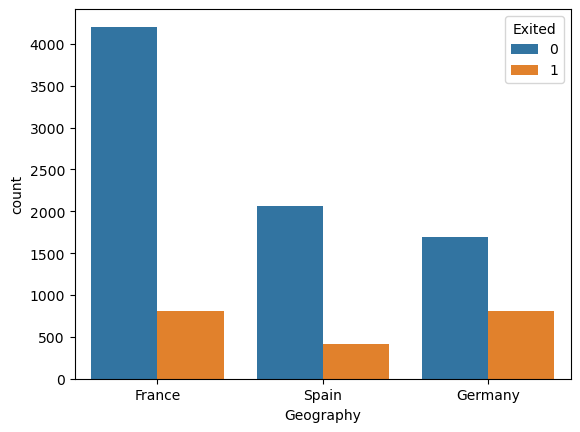

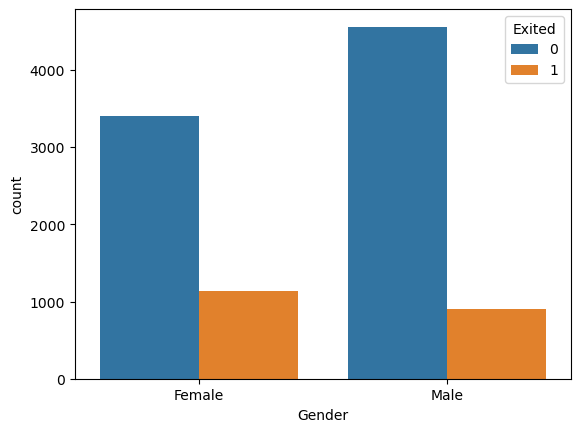

In [16]:
for i,predictor in enumerate(telco_new.drop(columns=['Exited'])):
    plt.figure()
    sns.countplot(data=telco_new,x=predictor,hue='Exited')

Bivariate Analysis

<Axes: xlabel='Gender', ylabel='Count'>

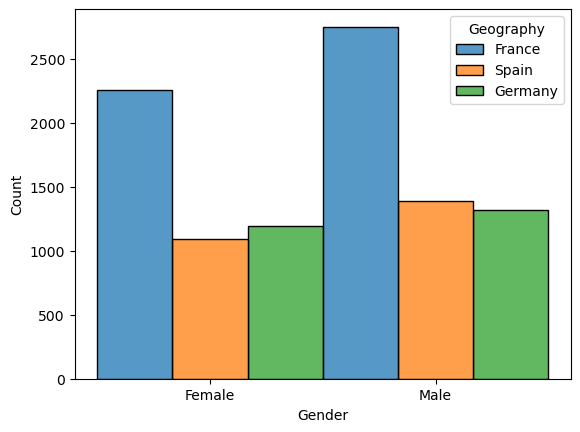

In [18]:
sns.histplot(x='Gender',hue='Geography',data=telco_new,stat="count",multiple="dodge")

In [ ]:
#this is the graph for original data

In [19]:
telco_new_target1=telco_new.loc[telco_new["Exited"]==1]


<Axes: xlabel='Gender', ylabel='Count'>

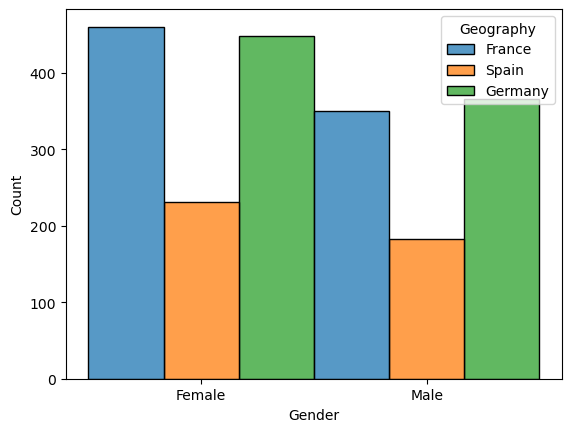

In [20]:
sns.histplot(x='Gender',hue='Geography',data=telco_new_target1,stat="count",multiple="dodge")

In [ ]:
#this is the graph for churn cusotmers

Numerical Analysis

In [21]:
#correlation:it ranges from +1 to -1
#+1-->Postive correlation
#-1-->Negative correlation
#~0-->no correlation

In [26]:
# Option 1: Use numeric_only=True (pandas 1.5+)
telco_base_data1=telco_base_data.corr(numeric_only=True)
telco_base_data1.head(50)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


<Axes: >

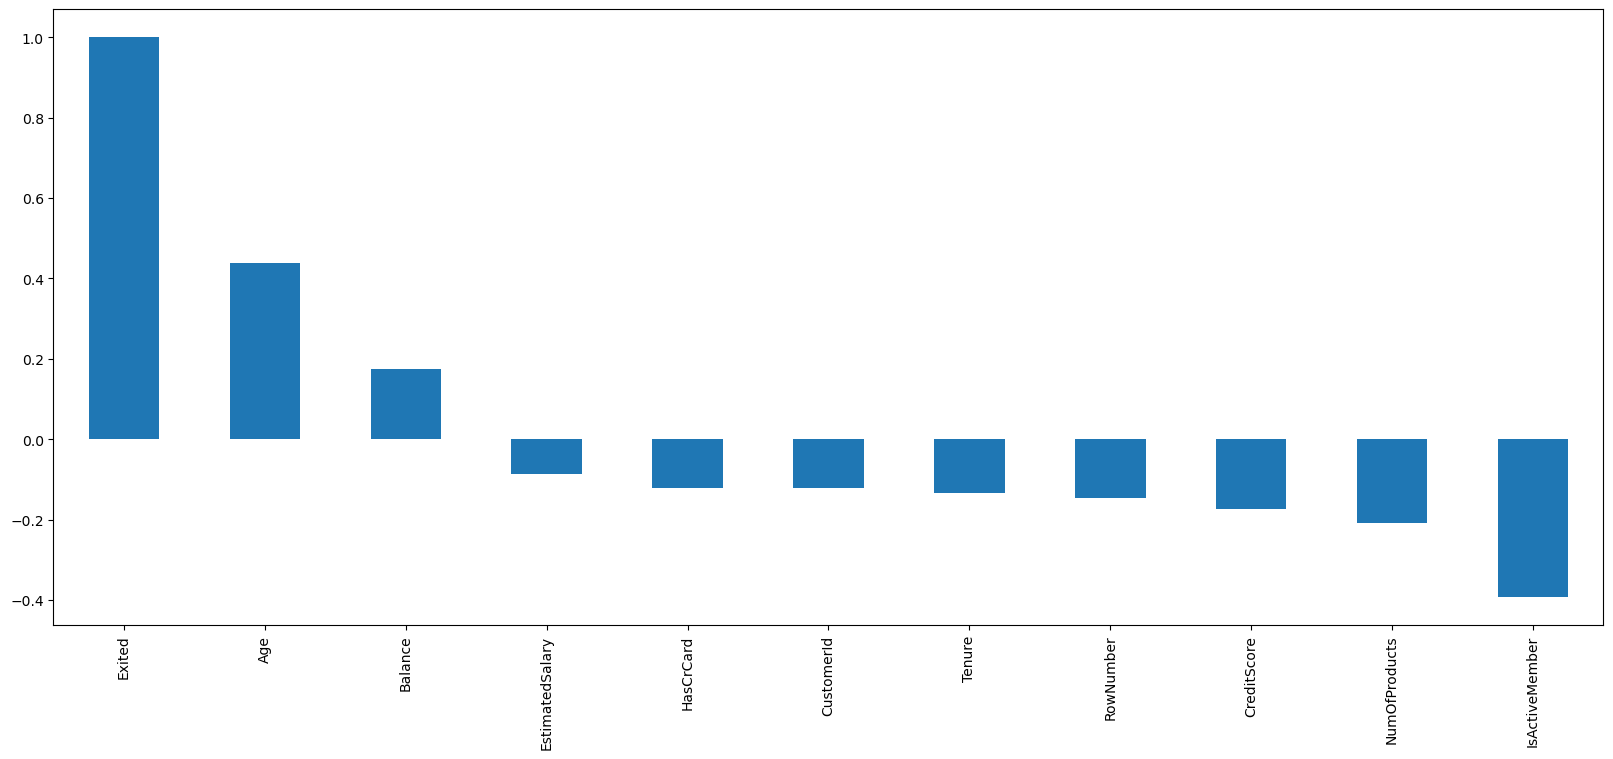

In [27]:
plt.figure(figsize=(20,8))
telco_base_data1.corr()['Exited'].sort_values(ascending=False).plot(kind='bar')

<Axes: >

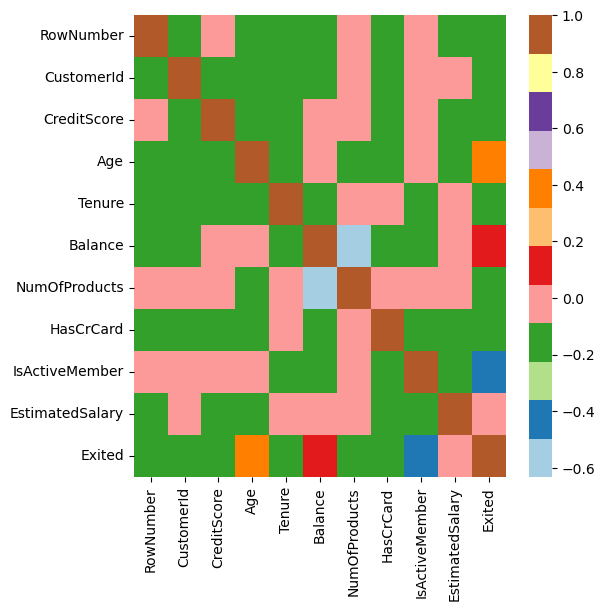

In [29]:
plt.figure(figsize=(6,6))
sns.heatmap(telco_base_data1.corr(),cmap='Paired')

<Axes: xlabel='Age'>

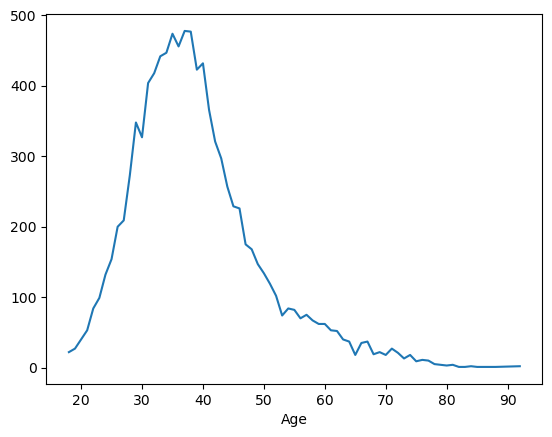

In [31]:
telco_base_data['Age'].value_counts().sort_index(ascending=True).plot()
#original data

In [36]:
telco_base_data2=telco_base_data.loc[telco_new["Exited"]==1]


<Axes: xlabel='Age'>

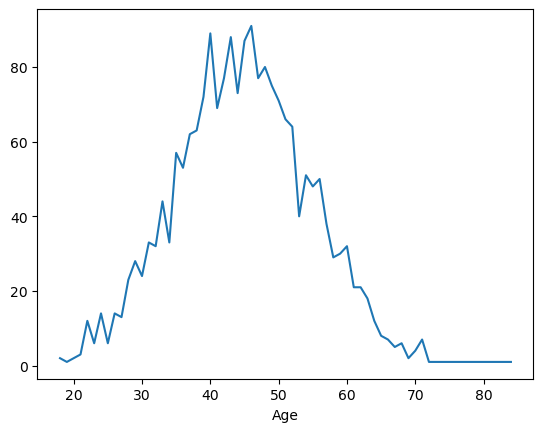

In [37]:
telco_base_data2['Age'].value_counts().sort_index(ascending=True).plot()
#churn data

Text(0.5, 1.0, 'Age by chrun')

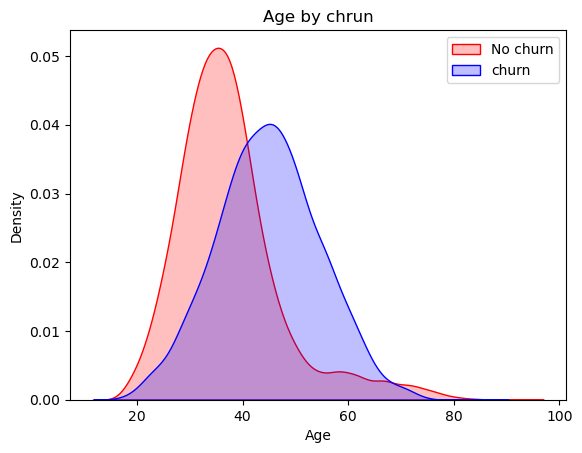

In [44]:
Tot=sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==0)],color="Red",fill=True)
Tot=sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==1)],color="Blue",fill=True)
Tot.legend(["No churn","churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Age')
Tot.set_title('Age by chrun')

In [45]:
#here we can see how age is affecting 

Text(0.5, 1.0, 'Age by chrun')

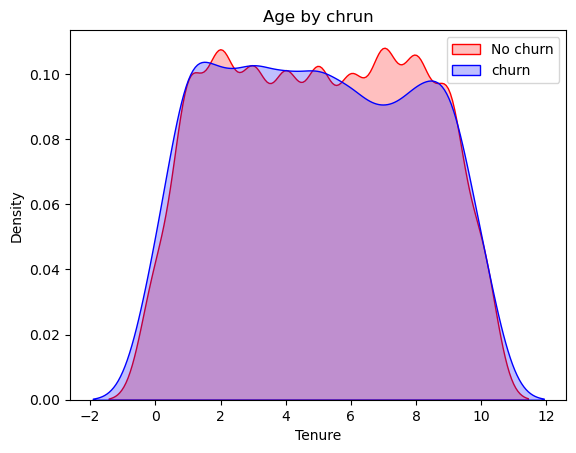

In [48]:
Tot=sns.kdeplot(telco_base_data.Tenure[(telco_base_data["Exited"]==0)],color="Red",fill=True)
Tot=sns.kdeplot(telco_base_data.Tenure[(telco_base_data["Exited"]==1)],color="Blue",fill=True)
Tot.legend(["No churn","churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Tenure')
Tot.set_title('Age by chrun')

In [47]:
#this shows that tenure doesnot affect much

Text(0.5, 1.0, 'Age by chrun')

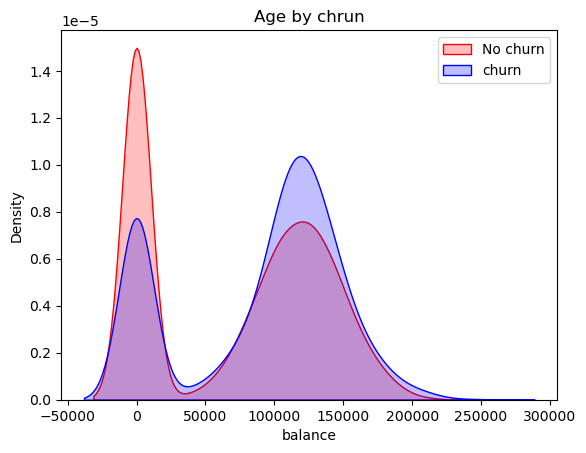

In [49]:
Tot=sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==0)],color="Red",fill=True)
Tot=sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==1)],color="Blue",fill=True)
Tot.legend(["No churn","churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('balance')
Tot.set_title('Age by chrun')